In [2344]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2345]:
#Disable scientific notation
pd.set_option('display.float_format', '{:.2f}'.format)

In [2346]:
#Display All the columns
pd.set_option('display.max_columns', None)

In [2347]:
#Display All the rows
pd.set_option('display.max_rows', None)

In [2348]:
# Suppress all warnings
import warnings
warnings.filterwarnings("ignore")

In [2349]:
# Suppress all warnings
import warnings
warnings.filterwarnings("ignore")

In [2350]:
df = pd.read_csv("day.csv")
df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.11,18.18,80.58,10.75,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.90,17.69,69.61,16.65,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.05,9.47,43.73,16.64,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.20,10.61,59.04,10.74,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.31,11.46,43.70,12.52,82,1518,1600
5,6,06-01-2018,1,0,1,0,6,0,1,8.38,11.66,51.83,6.00,88,1518,1606
6,7,07-01-2018,1,0,1,0,0,0,2,8.06,10.44,49.87,11.30,148,1362,1510
7,8,08-01-2018,1,0,1,0,1,1,2,6.76,8.11,53.58,17.88,68,891,959
8,9,09-01-2018,1,0,1,0,2,1,1,5.67,5.81,43.42,24.25,54,768,822
9,10,10-01-2018,1,0,1,0,3,1,1,6.18,7.54,48.29,14.96,41,1280,1321


# EDA

In [2352]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [2353]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00
mean,365.50,2.50,0.50,6.53,0.03,3.00,0.69,1.39,20.32,23.73,62.77,12.76,849.25,3658.76,4508.01
std,210.88,1.11,0.50,3.45,0.17,2.00,0.46,0.54,7.51,8.15,14.24,5.20,686.48,1559.76,1936.01
min,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,2.42,3.95,0.00,1.50,2.00,20.00,22.00
25%,183.25,2.00,0.00,4.00,0.00,1.00,0.00,1.00,13.81,16.89,52.00,9.04,316.25,2502.25,3169.75
50%,365.50,3.00,0.50,7.00,0.00,3.00,1.00,1.00,20.47,24.37,62.62,12.13,717.00,3664.50,4548.50
75%,547.75,3.00,1.00,10.00,0.00,5.00,1.00,2.00,26.88,30.45,72.99,15.63,1096.50,4783.25,5966.00
max,730.00,4.00,1.00,12.00,1.00,6.00,1.00,3.00,35.33,42.04,97.25,34.00,3410.00,6946.00,8714.00


In [2354]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [2355]:
# Check for duplicates 
df.duplicated().sum()

0

In [2356]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.11,18.18,80.58,10.75,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.90,17.69,69.61,16.65,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.05,9.47,43.73,16.64,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.20,10.61,59.04,10.74,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.31,11.46,43.70,12.52,82,1518,1600


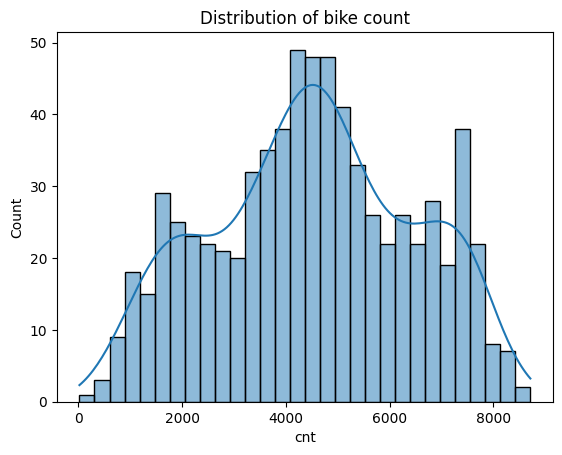

In [2357]:
sns.histplot(df['cnt'], bins=30, kde=True)
plt.title("Distribution of bike count")
plt.show()
# We can observe that there is a normal distribution of the data points

# Dropping unnecessary columns instant, dteday, casual & registered

## instant – It is just a sequence number of rows
## dteday – It is not required since columns for year & month already exists
## casual – This variable cannot be predicted.
## registered – This variable cannot be predicted

In [2359]:
#droping above columns 
df.drop(columns = ["instant","dteday", "casual", "registered"], axis = 1, inplace = True)
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,1,1,2,14.11,18.18,80.58,10.75,985
1,1,0,1,0,2,1,2,14.90,17.69,69.61,16.65,801
2,1,0,1,0,3,1,1,8.05,9.47,43.73,16.64,1349
3,1,0,1,0,4,1,1,8.20,10.61,59.04,10.74,1562
4,1,0,1,0,5,1,1,9.31,11.46,43.70,12.52,1600


# Outlier Detection 

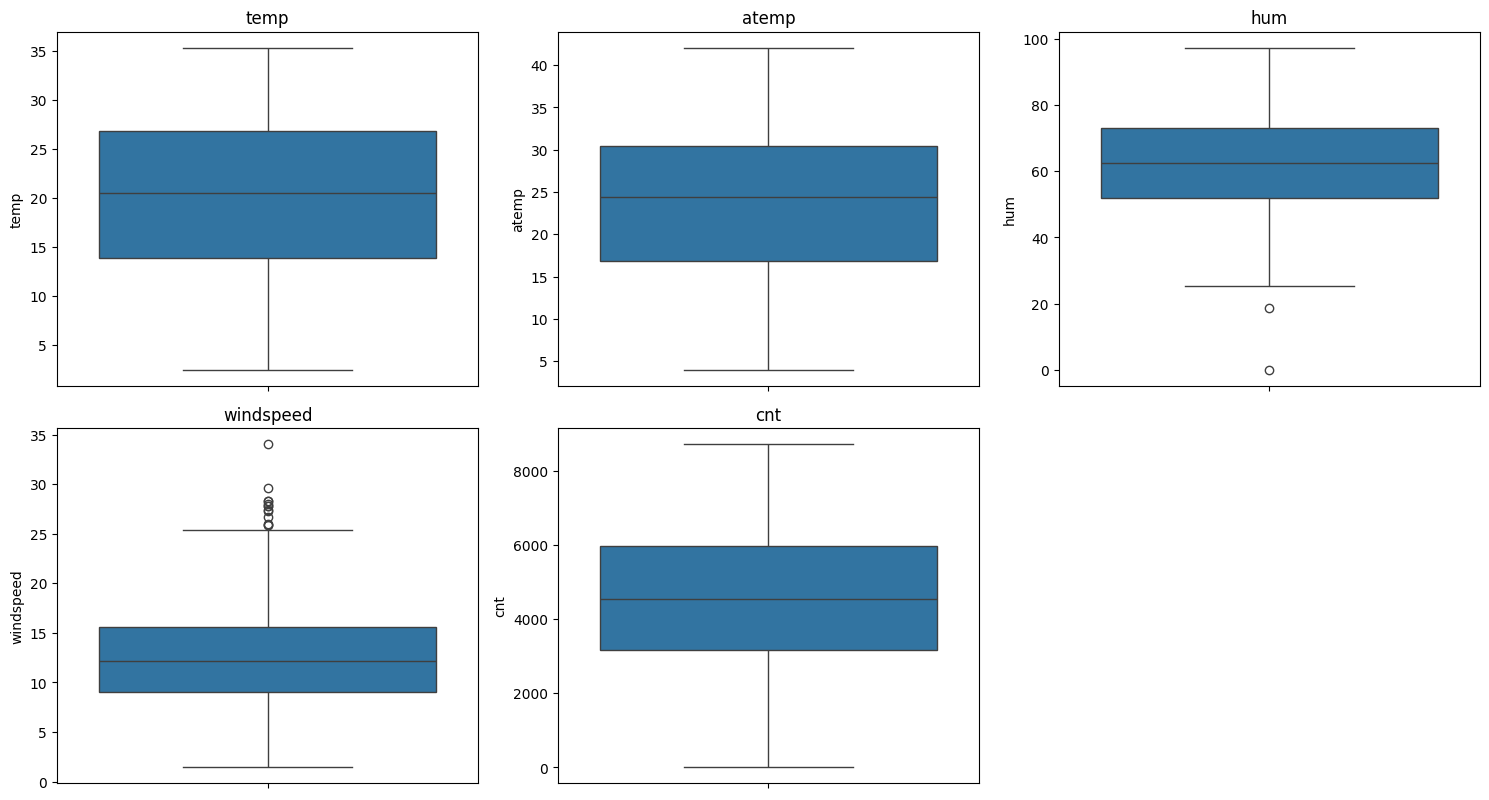

In [2361]:
# List of numerical columns
num_columns  = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']

# Set figure size
plt.figure(figsize=(15, 12))

# Create box plots for each numerical column
for i, col in enumerate(num_columns, 1):
    plt.subplot(3, 3, i)  # Creating a 3x3 grid of subplots
    sns.boxplot(y=df[col])  # Use 'bike' instead of 'df'
    plt.title(col)

plt.tight_layout()
plt.show()

# Outlier Treatment 

In [2363]:
Outlier_col = ['hum', 'windspeed']

for col in Outlier_col:
    q1=df[col].quantile(0.25) # Q1 - 25th Percentile
    q3=df[col].quantile(0.75) # Q3 - 75th Percentile
    iqr=q3-q1                     # IQR - InterQuartile Range
    lower_whisker=q1-1.5*iqr      # Lower Bound
    upper_whisker=q3+1.5*iqr      # Upper Bound
    df[col]=np.where(df[col]>upper_whisker,upper_whisker,df[col]) #Capping
    df[col]=np.where(df[col]<lower_whisker,lower_whisker,df[col]) #Flooring

# Outlier Detection - if it is treated 

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')


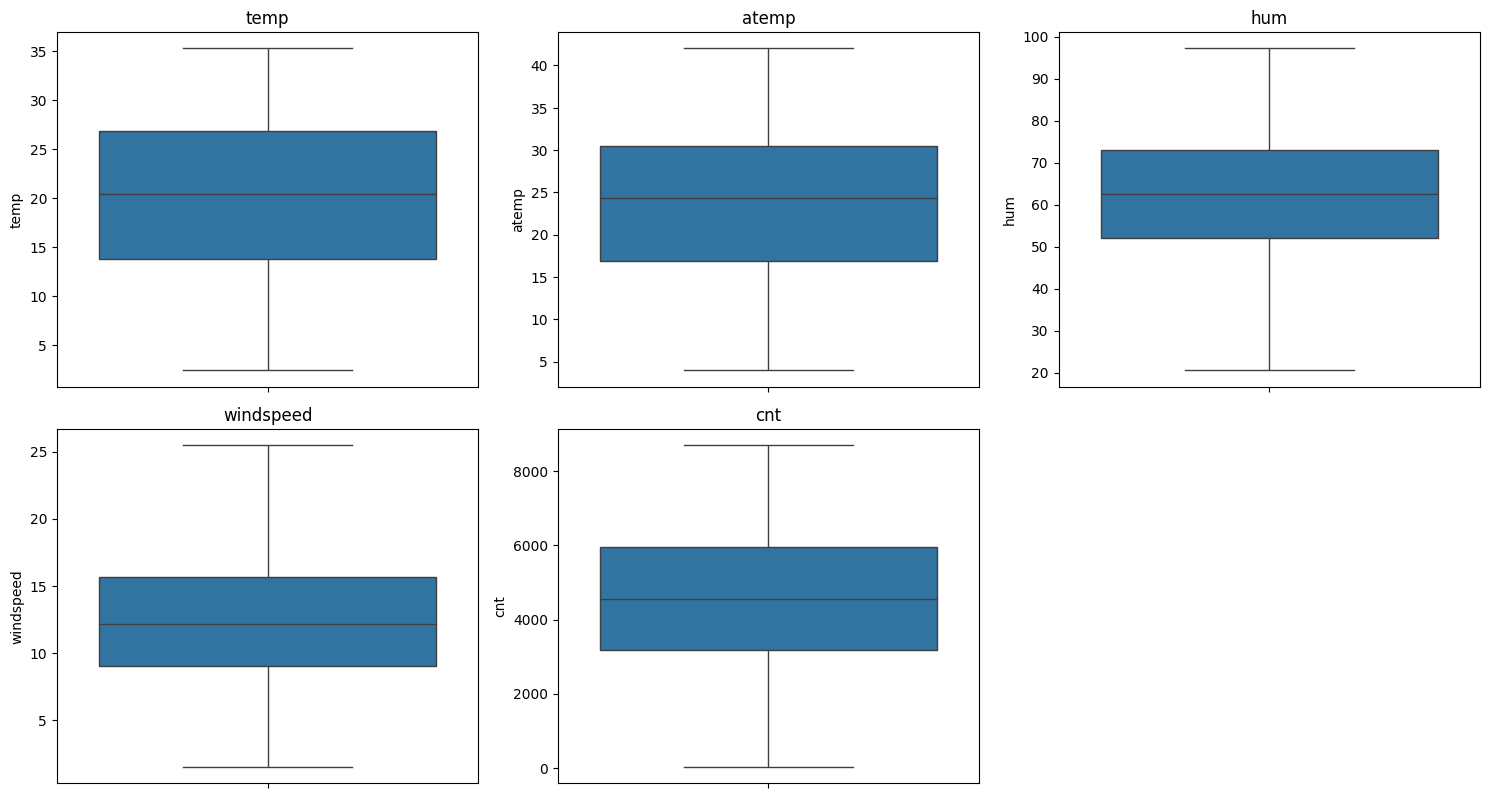

In [2365]:
# List of numerical columns
import matplotlib.pyplot as plt
import seaborn as sns

# Verify dataset name
print(df.columns)  # Check available column names

# List of numerical columns
num_columns =  ['temp', 'atemp', 'hum', 'windspeed', 'cnt']

# Set figure size
plt.figure(figsize=(15, 12))

# Create box plots for each numerical column
for i, col in enumerate(num_columns, 1):
    plt.subplot(3, 3, i)  # Creating a 3x3 grid of subplots
    sns.boxplot(y=df[col])  # Use 'bike' instead of 'df'
    plt.title(col)

plt.tight_layout()
plt.show()

# Visualization of the data

In [2367]:
df.columns

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

In [2368]:
df.columns

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

In [2369]:
# mapping values in catagrical columns   

In [2370]:
df["yr"] = df["yr"].replace({0: "2018", 1:"2019"})
df["season"] = df["season"].replace({1:"spring", 2:"summer", 3:"fall", 4:"winter"})
df["mnth"] = df["mnth"].replace({1:"January", 2:"Febuary", 3:"March", 4:"Arpril",5:"May", 6:"June", 7:"July", 8:"August",9:"September", 10:"October", 11:"November", 12:"Decemeber"})
df["weekday"] = df["weekday"].replace({1:"Monday", 2:"Tuesday", 3:"Wednesday", 4:"Thursday",5:"Friday", 6:"Saturday", 0:"Sunday"})
df["weathersit"] = df["weathersit"].replace({1:"Clear", 2:"Cloudy", 3:"Snow", 4:"Heavy Rain"})
df["workingday"] = df["workingday"].replace({0:"Yes", 1:"No"})
df["holiday"] = df["holiday"].replace({0:"Yes", 1:"No"})
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,spring,2018,January,Yes,Monday,No,Cloudy,14.11,18.18,80.58,10.75,985
1,spring,2018,January,Yes,Tuesday,No,Cloudy,14.90,17.69,69.61,16.65,801
2,spring,2018,January,Yes,Wednesday,No,Clear,8.05,9.47,43.73,16.64,1349
3,spring,2018,January,Yes,Thursday,No,Clear,8.20,10.61,59.04,10.74,1562
4,spring,2018,January,Yes,Friday,No,Clear,9.31,11.46,43.70,12.52,1600


In [2371]:
df.dtypes

season         object
yr             object
mnth           object
holiday        object
weekday        object
workingday     object
weathersit     object
temp          float64
atemp         float64
hum           float64
windspeed     float64
cnt             int64
dtype: object

In [2372]:
# Segragating catagoical and numerical columns
Cat_Col = []
Num_Col = []

for i in df.columns:
    if df[i].dtypes == "object":
        Cat_Col.append(i)
    else:
        Num_Col.append(i)

print(Num_Col)
print(Cat_Col)

['temp', 'atemp', 'hum', 'windspeed', 'cnt']
['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']


# Univariate Analysis of Cat_Col i.e., Catagorical Data:

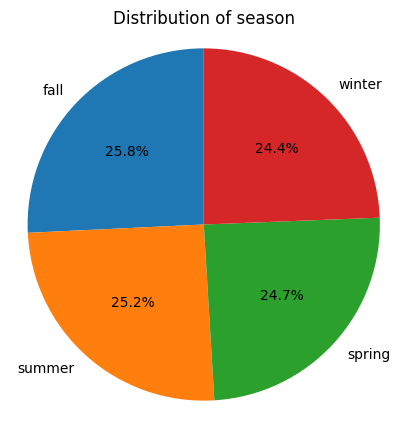

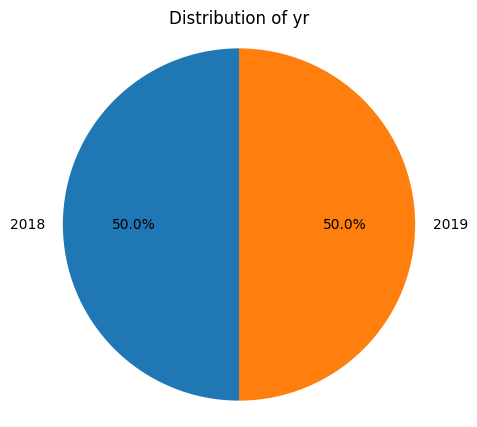

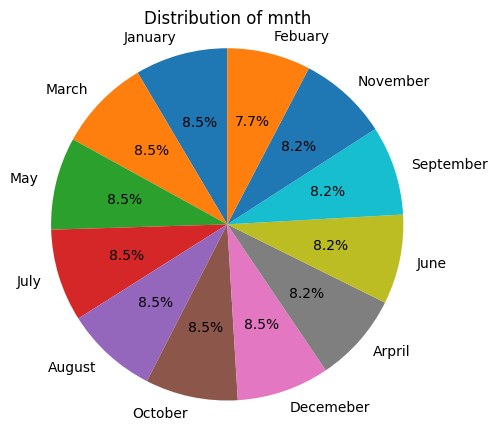

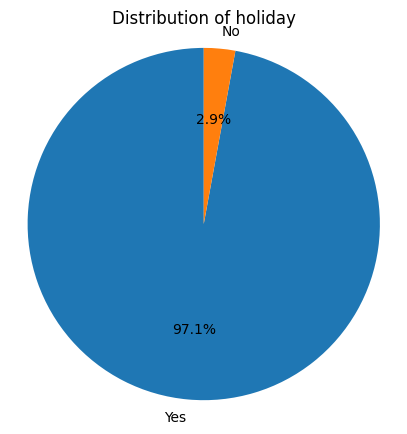

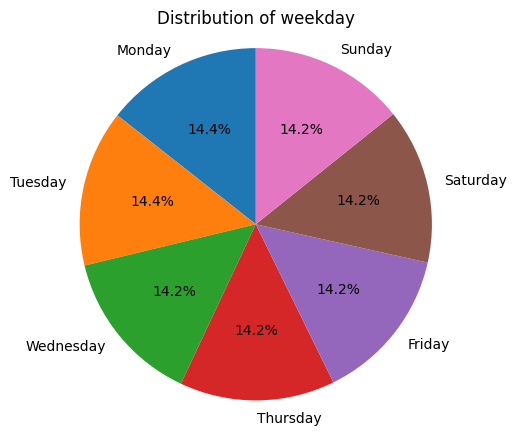

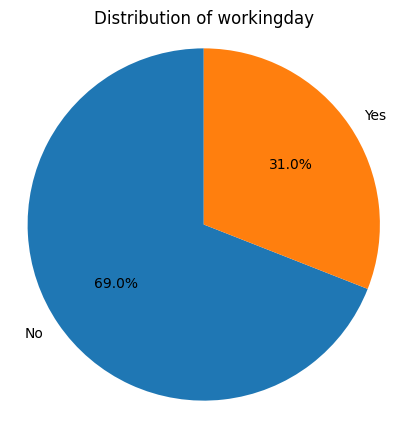

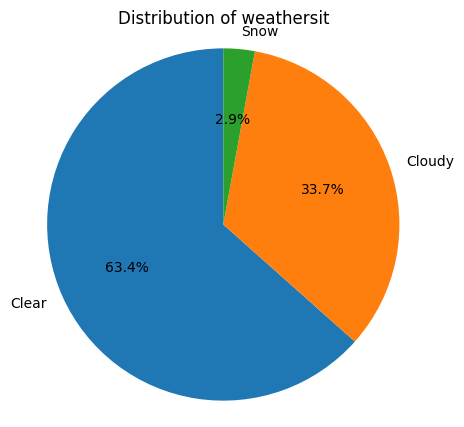

In [2374]:
for col in Cat_Col:
    counts = df[col].value_counts()  # Get counts of each category
    labels = counts.index
    values = counts.values

    plt.figure(figsize=(5, 5))
    plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title(f'Distribution of {col}')
    plt.axis('equal')  # Keeps pie chart circular
    plt.show()

# Analysis¶

Almost all the graphs are equally distributed exept;

"Distribution of Holiday", the value of holidays is only 3%.

"Distribution of Working day", the value of non-working days is only 31%.

"Distribution of weather slit", mostly the weather is clear i.e., 63% or mist+cloudy i.e., 33% and there is only 3% chance that it will rain or snow

# Univariate Analysis of Num_Col i.e., Numerical Data:

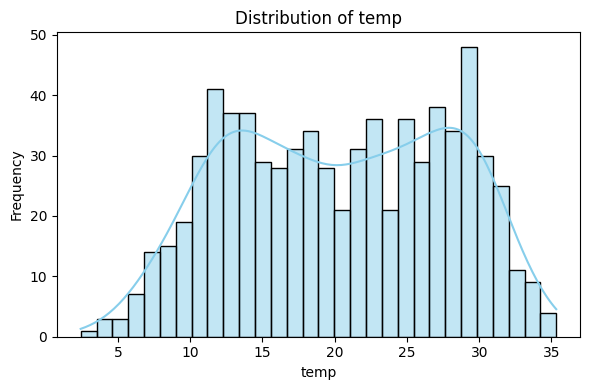

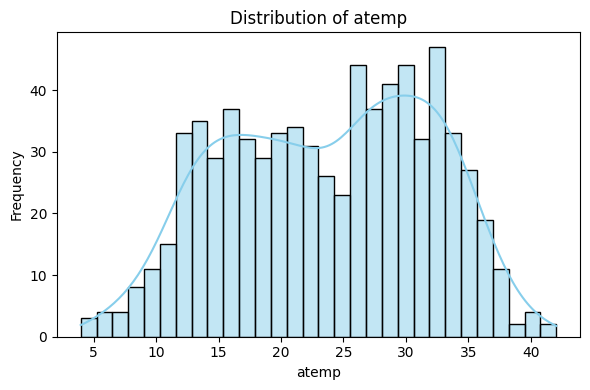

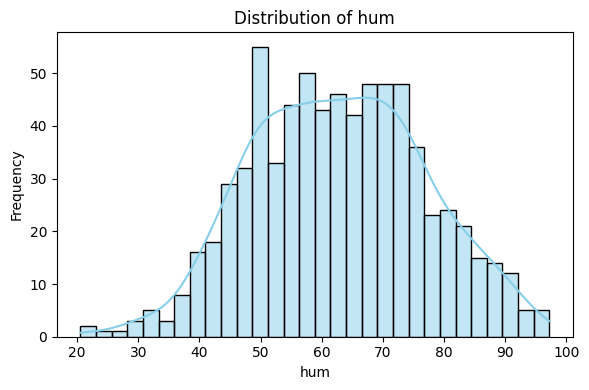

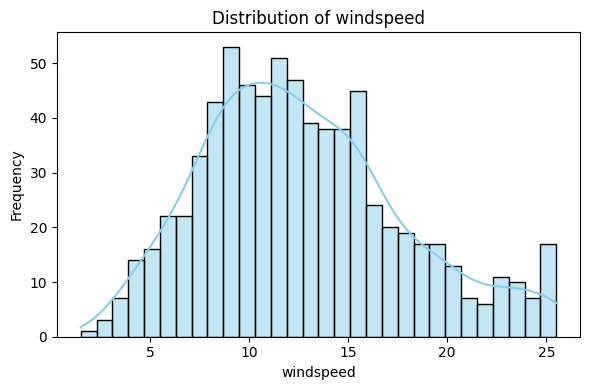

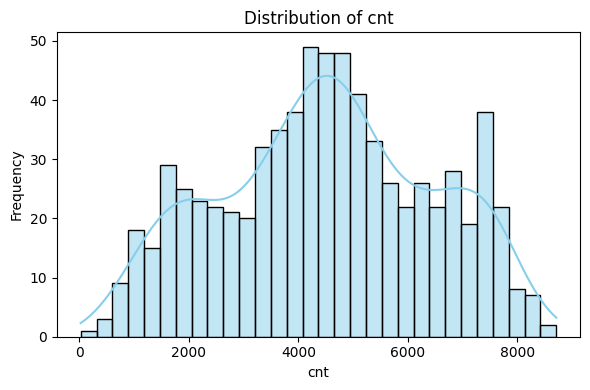

In [2377]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in Num_Col:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# 📊 Visual Observations:

# temp & atemp:

Both appear roughly bell-shaped (symmetric), close to normal distribution.

✅ Good for linear regression — it handles normally distributed predictors well.

# hum (Humidity):

    Slight left skew with a concentration around 60–80.

Still fairly usable, but if skew impacts performance, you might apply a transformation.

# windspeed:

Appears right-skewed.

This could reduce the effectiveness of linear models unless transformed (e.g., log, sqrt).

cnt (Target variable — total rentals):

Also multi-modal and slightly skewed.

Linear regression assumes that residuals of predictions (not the target itself) should be normally distributed. But still, a skewed target may affect performance.

Consider log-transforming cnt (log1p(cnt)) if needed.

# Bivariate Analysis of Num_Col i.e., Numerical Data:

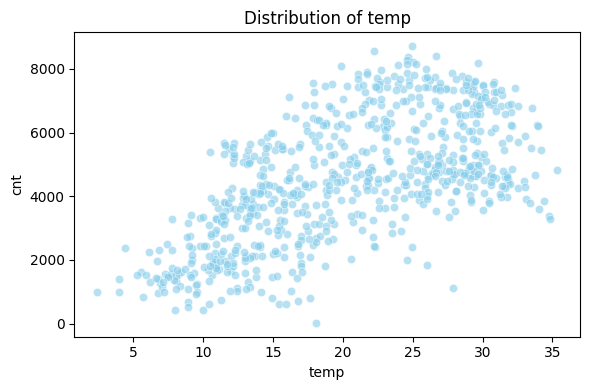

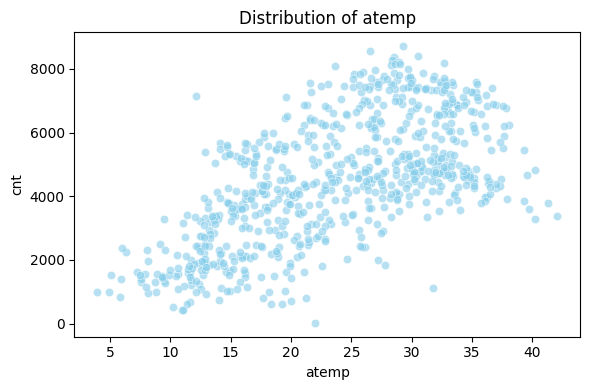

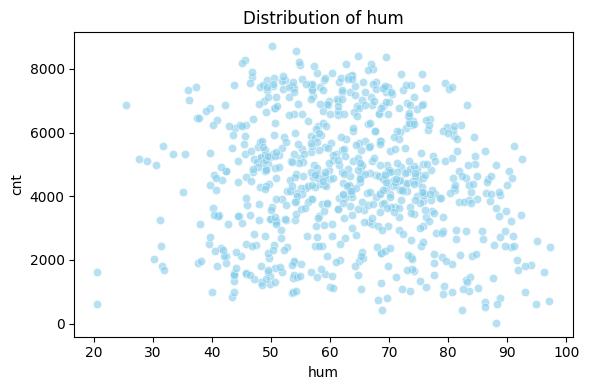

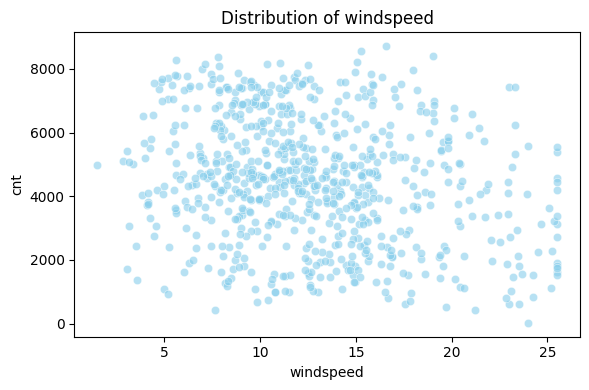

In [2380]:
new = ['temp', 'atemp', 'hum', 'windspeed']
for col in new:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x = df[col], y =  df["cnt"], color='skyblue', alpha = 0.6)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('cnt')
    plt.tight_layout()
    plt.show()

What Do the Scatterplots Show?
#temp vs cnt ✅ Clear positive linear trend — as temperature increases, rentals (cnt) increase. → Definitely a good candidate for linear regression.

atemp vs cnt
✅ Also shows a strong positive linear relationship.

hum vs cnt
❌ No clear linear trend — it's more scattered, maybe weak or even a slight negative trend. → Might not help linear regression much on its own, but could still be useful in non-linear models or with interaction terms.

windspeed vs cnt
❌ Looks like random noise — no obvious trend at all. → Probably not useful for linear regression unless you apply transformations or use it in ensemble models.

# Bivariate Analysis of Cat_Col i.e., Catagorical Data:¶

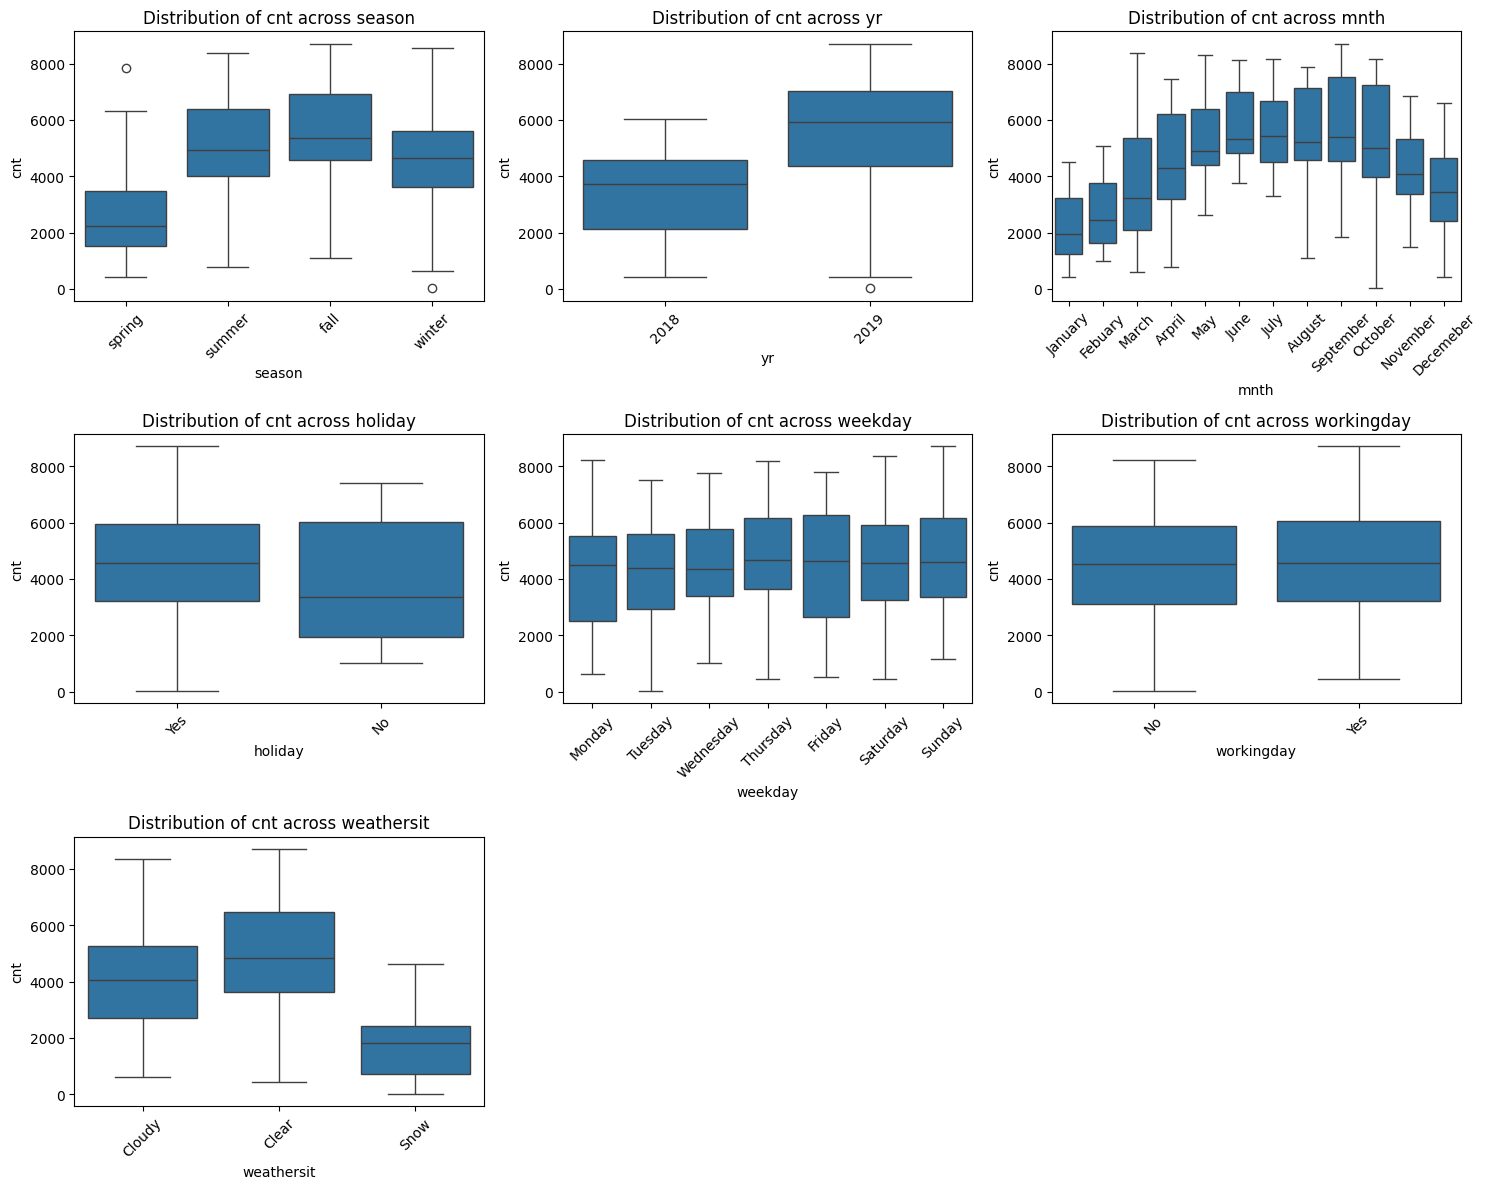

In [2383]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(15, 12))

# Loop through each categorical column and create a subplot
for i, col in enumerate(Cat_Col, 1):  # Start index from 1
    plt.subplot(3, 3, i)  # 3x3 grid
    sns.boxplot(x=df[col], y=df['cnt'])
    plt.title(f'Distribution of cnt across {col}')
    plt.xlabel(col)
    plt.ylabel('cnt')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Feature-by-Feature Insights:

# 1. season
Summer & Fall show higher median bike counts.

Winter & Spring show lower medians. ✅ Use it — this is informative and shows seasonal trends.

# 2. yr
2019 (encoded as 1) has much higher counts than 2018 (0). ✅ Strong predictor — definitely keep it.

# 3. mnth
Gradual increase from Jan to peak in May–Sept, then decline.

High variance in summer months. ✅ Include — but consider converting month to cyclical features (sin/cos) for better linear modeling.

# 4. holiday
Slightly lower usage on holidays, but not a drastic difference. ⚠️ Optional — weak signal. May not help much.

# 5. weekday
Almost flat boxplots — similar distributions from Mon to Sun. ❌ Not useful for linear regression — likely to have low predictive power.

# 6. workingday
Slightly higher medians on working days. ⚠️ Could include — but only if interaction with other features (e.g., hour) is important.

# 7. weathersit
Clear differences:

Clear weather has highest counts.

Light snow/rain drops counts drastically. ✅ Definitely include — useful predictor of usage.

# Multivariate Analysis

In [2386]:
df.corr()

,temp,atemp,hum,windspeed,cnt
temp,1.00,0.99,0.13,-0.16,0.63
atemp,0.99,1.00,0.14,-0.18,0.63
hum,0.13,0.14,1.00,-0.24,-0.10
windspeed,-0.16,-0.18,-0.24,1.00,-0.23
cnt,0.63,0.63,-0.10,-0.23,1.00


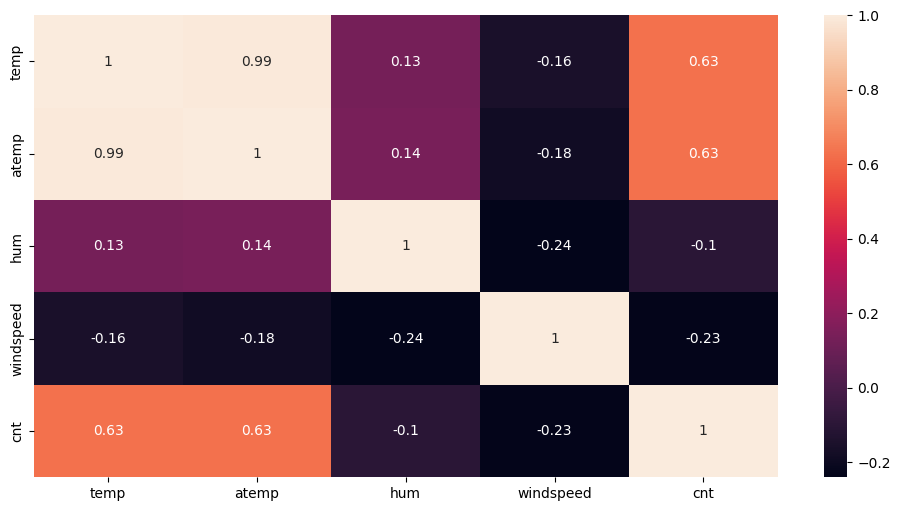

In [2387]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [2388]:
df["yr"] = df["yr"].replace({"2018":0 ,"2019":1})
df["workingday"] = df["workingday"].replace({"Yes":0, "No":1})
df["holiday"] = df["holiday"].replace({"Yes":0, "No":1})
df

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,spring,0,January,0,Monday,1,Cloudy,14.11,18.18,80.58,10.75,985
1,spring,0,January,0,Tuesday,1,Cloudy,14.90,17.69,69.61,16.65,801
2,spring,0,January,0,Wednesday,1,Clear,8.05,9.47,43.73,16.64,1349
3,spring,0,January,0,Thursday,1,Clear,8.20,10.61,59.04,10.74,1562
4,spring,0,January,0,Friday,1,Clear,9.31,11.46,43.70,12.52,1600
5,spring,0,January,0,Saturday,0,Clear,8.38,11.66,51.83,6.00,1606
6,spring,0,January,0,Sunday,0,Cloudy,8.06,10.44,49.87,11.30,1510
7,spring,0,January,0,Monday,1,Cloudy,6.76,8.11,53.58,17.88,959
8,spring,0,January,0,Tuesday,1,Clear,5.67,5.81,43.42,24.25,822
9,spring,0,January,0,Wednesday,1,Clear,6.18,7.54,48.29,14.96,1321


# Pre-processing Steps
## Dummy Variable Creation (One Hot Encoding)

In [2390]:
df = pd.get_dummies(data = df, columns = ['season', 'mnth', 'weekday', 'weathersit'], drop_first = True)

In [2391]:
df.shape

(730, 30)

In [2392]:
# Inspecting the columns in dataframe
df.columns

Index(['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed',
       'cnt', 'season_spring', 'season_summer', 'season_winter', 'mnth_August',
       'mnth_Decemeber', 'mnth_Febuary', 'mnth_January', 'mnth_July',
       'mnth_June', 'mnth_March', 'mnth_May', 'mnth_November', 'mnth_October',
       'mnth_September', 'weekday_Monday', 'weekday_Saturday',
       'weekday_Sunday', 'weekday_Thursday', 'weekday_Tuesday',
       'weekday_Wednesday', 'weathersit_Cloudy', 'weathersit_Snow'],
      dtype='object')

# Split into Features (X) and Target (y)

In [2394]:
# Getting the feature variables in X and dependent variable `cnt` in y
X = df.drop('cnt', axis = 1)
y = df['cnt']

In [2395]:
# Splitting the data into a 70% training set and a 30% test set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 100)

In [2396]:
# Checking shape and size for train and test set
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(511, 29)
(511,)
(219, 29)
(219,)


In [2397]:
# Inspect the head of the training set
X_train.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,season_spring,season_summer,season_winter,mnth_August,mnth_Decemeber,mnth_Febuary,mnth_January,mnth_July,mnth_June,mnth_March,mnth_May,mnth_November,mnth_October,mnth_September,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_Cloudy,weathersit_Snow
653,1,0,1,19.20,23.04,55.83,12.21,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
576,1,0,1,29.25,33.14,70.42,11.08,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
426,1,0,0,16.98,20.67,62.12,10.79,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0
728,1,0,1,10.49,11.59,48.33,23.50,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
482,1,0,0,15.44,18.88,48.96,8.71,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0


# Feature Scaling

In [2399]:
# Use StandardScaler to scale values
scaler = StandardScaler()

# Fit and transform training set
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns = X_train.columns, index = X_train.index)

# Only Transform Test set
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns, index = X_test.index)

In [2400]:
# Inspect the training set after scaling
X_train_scaled.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,season_spring,season_summer,season_winter,mnth_August,mnth_Decemeber,mnth_Febuary,mnth_January,mnth_July,mnth_June,mnth_March,mnth_May,mnth_November,mnth_October,mnth_September,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_Cloudy,weathersit_Snow
653,0.98,-0.16,0.64,-0.12,-0.06,-0.52,-0.11,-0.57,-0.57,1.74,-0.33,-0.30,-0.27,-0.31,-0.29,-0.29,-0.33,-0.30,-0.31,3.26,-0.30,-0.43,-0.39,-0.40,-0.41,-0.42,2.51,-0.72,-0.17
576,0.98,-0.16,0.64,1.23,1.19,0.52,-0.33,-0.57,-0.57,-0.58,-0.33,-0.30,-0.27,-0.31,3.48,-0.29,-0.33,-0.30,-0.31,-0.31,-0.30,-0.43,-0.39,-0.40,-0.41,-0.42,2.51,-0.72,-0.17
426,0.98,-0.16,-1.57,-0.42,-0.35,-0.07,-0.39,1.77,-0.57,-0.58,-0.33,-0.30,-0.27,-0.31,-0.29,-0.29,3.04,-0.30,-0.31,-0.31,-0.30,-0.43,-0.39,2.51,-0.41,-0.42,-0.40,1.38,-0.17
728,0.98,-0.16,0.64,-1.30,-1.48,-1.06,2.09,1.77,-0.57,-0.58,-0.33,3.30,-0.27,-0.31,-0.29,-0.29,-0.33,-0.30,-0.31,-0.31,-0.30,2.34,-0.39,-0.40,-0.41,-0.42,-0.40,-0.72,-0.17
482,0.98,-0.16,-1.57,-0.63,-0.57,-1.02,-0.79,-0.57,1.75,-0.58,-0.33,-0.30,-0.27,-0.31,-0.29,-0.29,-0.33,-0.30,-0.31,-0.31,-0.30,-0.43,-0.39,2.51,-0.41,-0.42,-0.40,1.38,-0.17


In [2401]:
# Create and train the model with RFE
lm = LinearRegression()

rfe = RFE(lm, n_features_to_select = 12)

rfe = rfe.fit(X_train_scaled, y_train)

In [2402]:
rfe.support_

array([ True,  True, False,  True, False,  True,  True,  True,  True,
        True, False, False, False, False,  True, False, False, False,
       False, False,  True, False, False, False, False, False, False,
        True,  True])

In [2403]:
list(zip(X_train_scaled.columns, rfe.support_, rfe.ranking_))

[('yr', True, 1),
 ('holiday', True, 1),
 ('workingday', False, 5),
 ('temp', True, 1),
 ('atemp', False, 11),
 ('hum', True, 1),
 ('windspeed', True, 1),
 ('season_spring', True, 1),
 ('season_summer', True, 1),
 ('season_winter', True, 1),
 ('mnth_August', False, 13),
 ('mnth_Decemeber', False, 4),
 ('mnth_Febuary', False, 8),
 ('mnth_January', False, 2),
 ('mnth_July', True, 1),
 ('mnth_June', False, 15),
 ('mnth_March', False, 18),
 ('mnth_May', False, 12),
 ('mnth_November', False, 3),
 ('mnth_October', False, 16),
 ('mnth_September', True, 1),
 ('weekday_Monday', False, 10),
 ('weekday_Saturday', False, 6),
 ('weekday_Sunday', False, 7),
 ('weekday_Thursday', False, 17),
 ('weekday_Tuesday', False, 9),
 ('weekday_Wednesday', False, 14),
 ('weathersit_Cloudy', True, 1),
 ('weathersit_Snow', True, 1)]

In [2404]:
selected_features = X_train_scaled.columns[rfe.support_]
selected_features

Index(['yr', 'holiday', 'temp', 'hum', 'windspeed', 'season_spring',
       'season_summer', 'season_winter', 'mnth_July', 'mnth_September',
       'weathersit_Cloudy', 'weathersit_Snow'],
      dtype='object')

In [2405]:
# Get the columns which are rejected using RFE approach
rejected_features = X_train_scaled.columns[~rfe.support_]

In [2406]:
# Verifying column names which are rejected
rejected_features

Index(['workingday', 'atemp', 'mnth_August', 'mnth_Decemeber', 'mnth_Febuary',
       'mnth_January', 'mnth_June', 'mnth_March', 'mnth_May', 'mnth_November',
       'mnth_October', 'weekday_Monday', 'weekday_Saturday', 'weekday_Sunday',
       'weekday_Thursday', 'weekday_Tuesday', 'weekday_Wednesday'],
      dtype='object')

### Common Utility Functions

In [2408]:
def calculate_VIF(X_train):
    """
    Calculate Variance Inflation Factor (VIF) for features in the training set.

    VIF measures the extent to which the variance of an independent variable is inflated by the existence of other 
    independent variables in the model. High VIF values indicate strong correlation between variables.

    Parameters:
    - X_train (pd.DataFrame): Input features in the training set.

    Returns:
    - pd.DataFrame: DataFrame containing Features and their corresponding VIF values.
    """
    vif = pd.DataFrame()
    vif["Features"] = X_train.columns
    vif["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(len(X_train.columns))]
    
    vif['VIF'] = round(vif['VIF'], 2)
    return vif.sort_values(by = 'VIF', ascending = False)

In [2409]:
def generate_model_with_summary(X_train, y_train):
    """
    Generate and fit an Ordinary Least Squares (OLS) model using statsmodels,
    print the model summary, and return a dictionary with the fitted model and
    the features with an added constant term.

    Parameters:
    - X_train (DataFrame): Features for training.
    - y_train (Series): Target variable for training.

    Returns:
    dict: A dictionary containing the fitted OLS model ('model') and the features
          with added constant term ('X_train_sm').
    """
    X_train_sm = sm.add_constant(X_train)
    lm = sm.OLS(y_train, X_train_sm).fit()
    print(lm.summary())
    return { 'model' : lm, 'X_train_sm' : X_train_sm }

# Model 1

In [2411]:
X_train_rfe_1 = X_train_scaled[selected_features]

In [2412]:
generate_model_with_summary(X_train_rfe_1, y_train)
calculate_VIF(X_train_rfe_1)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     220.6
Date:                Sat, 12 Apr 2025   Prob (F-statistic):          1.82e-190
Time:                        14:26:32   Log-Likelihood:                -4125.7
No. Observations:                 511   AIC:                             8277.
Df Residuals:                     498   BIC:                             8333.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              4491.3033     34.79

,Features,VIF
5,season_spring,5.02
2,temp,3.64
7,season_winter,3.50
6,season_summer,2.63
3,hum,1.95
10,weathersit_Cloudy,1.59
8,mnth_July,1.49
9,mnth_September,1.30
11,weathersit_Snow,1.28
4,windspeed,1.20


# Model 2

### Droping season_spring	as the VIF is grater than 5 i.e., 5.02

In [2415]:
X_train_rfe_2 = X_train_rfe_1.drop(['season_spring'], axis = 1)

In [2416]:
generate_model_with_summary(X_train_rfe_2, y_train)
calculate_VIF(X_train_rfe_2)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.839
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     237.0
Date:                Sat, 12 Apr 2025   Prob (F-statistic):          4.30e-190
Time:                        14:26:32   Log-Likelihood:                -4129.4
No. Observations:                 511   AIC:                             8283.
Df Residuals:                     499   BIC:                             8334.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              4491.3033     35.01

,Features,VIF
3,hum,1.93
2,temp,1.61
9,weathersit_Cloudy,1.58
7,mnth_July,1.43
5,season_summer,1.33
6,season_winter,1.29
10,weathersit_Snow,1.27
8,mnth_September,1.19
4,windspeed,1.18
0,yr,1.03


#### The model appears favorable, with a low Prob (F-statistic) of 2.46e-190, minimal p-values, VIF below 5 for all features, and $R^2$ and Adjusted $R^2$ values of 0.840 and 0.836. However, further refinement is planned to explore potential feature reduction without significant impact on $R^2$.

# Model 3

- ***Remove Month (`July`) because it has a marginal p-value of 0.008***

In [2419]:
X_train_rfe_3 = X_train_rfe_2.drop(['mnth_July'], axis = 1)

In [2420]:
final_lr_model = generate_model_with_summary(X_train_rfe_3, y_train)
calculate_VIF(X_train_rfe_3)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     256.9
Date:                Sat, 12 Apr 2025   Prob (F-statistic):          8.40e-190
Time:                        14:26:32   Log-Likelihood:                -4133.0
No. Observations:                 511   AIC:                             8288.
Df Residuals:                     500   BIC:                             8335.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              4491.3033     35.22

,Features,VIF
3,hum,1.91
8,weathersit_Cloudy,1.58
2,temp,1.28
9,weathersit_Snow,1.27
6,season_winter,1.25
5,season_summer,1.19
4,windspeed,1.18
7,mnth_September,1.11
0,yr,1.03
1,holiday,1.02


# Model Evaluation

*** Residual Analysis ***

Residual analysis is performed to assess the goodness of fit and identify patterns or anomalies in the model's predictions.

In [2423]:
# Fetch the final model and the X_train_sm from the final_lr_model
model, X_train_sm = final_lr_model.values()

In [2424]:
# Calculate y_train_pred
y_train_pred = model.predict(X_train_sm)

Linear regression models are based on several key assumptions:

1. **Linearity:** The relationship between the independent and dependent variables is assumed to be linear.

2. **Independence:** Residuals (the differences between observed and predicted values) should be independent of each other.

3. **Homoscedasticity:** The variance of residuals should be constant across all levels of the independent variables, indicating consistent levels of variability.

4. **Normality of Residuals:** The residuals should be approximately normally distributed.

5. **No Perfect Multicollinearity:** Independent variables should not exhibit high correlation with each other, avoiding multicollinearity issues.

Violation of these assumptions can affect the accuracy and reliability of the linear regression model, and diagnostic checks are often performed to assess adherence to these assumptions.

<Figure size 800x500 with 0 Axes>

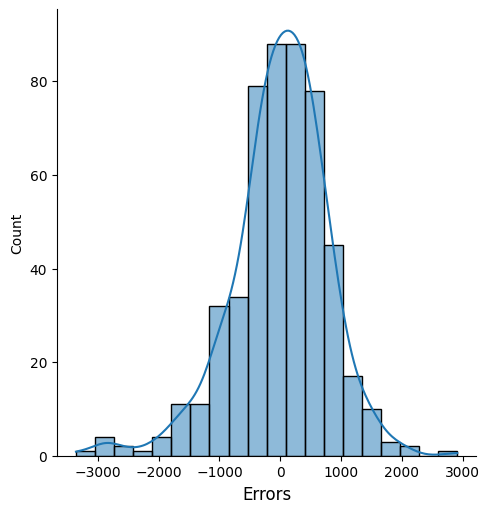

In [2426]:
# Plot the histogram of the error terms on the training set
residuals = y_train - y_train_pred
fig = plt.figure(figsize = (8, 5))
sns.displot(residuals, bins = 20, kde = True)
plt.xlabel('Errors', fontsize = 12)
plt.show()

In [2427]:
# The error terms follow the principle of a normal distribution curve

## Homoscedasticity

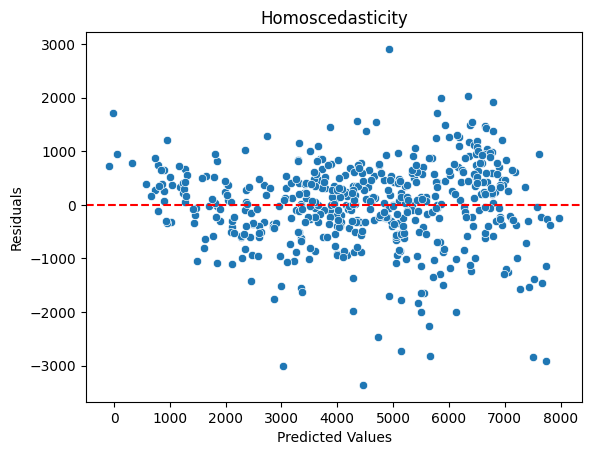

In [2429]:
# Visualize Homoscedasticity
sns.scatterplot(x = y_train_pred, y = residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Homoscedasticity')
plt.axhline(y = 0, color = 'r', linestyle = '--')
plt.show()

## Random Scatter: The residuals (errors) are randomly spread across all levels of predicted values. This is exactly what we want — it means the model’s error is consistent across the range of predictions.

## No Funnel Shape: There’s no clear pattern, such as a cone/funnel (which would indicate heteroscedasticity).

## Centered Around Zero: Most residuals are centered around the red line at y = 0, which shows that your model's predictions are unbiased on average.

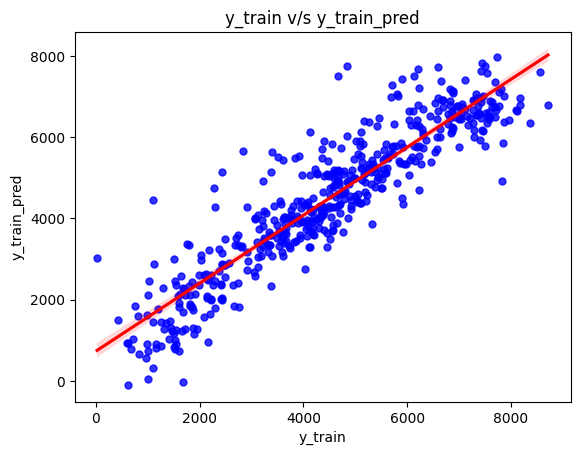

In [2431]:
# Visualize the trained model using a scatter plot with a linear regression fit line
sns.regplot(x = y_train, y = y_train_pred, line_kws = { 'color': 'red' }, scatter_kws = { 's' : 25, 'color': 'blue' })

# Show the plot
plt.title('y_train v/s y_train_pred')
plt.xlabel('y_train')
plt.ylabel('y_train_pred') 
plt.show()

In [2432]:
# Calculate mean squared error of the training set
mse_train = mean_squared_error(y_train, y_train_pred)

# Calculate RMSE
rmse_train = np.sqrt(mse_train)

print(rmse_train)

787.7262952803883


In [2433]:
print("Mean of target:", y_train.mean())
print("RMSE:", rmse_train)

Mean of target: 4491.303326810176
RMSE: 787.7262952803883


In [2434]:
# The linear model's assumptions hold, indicating it is well-trained and ready for testing on the test set.
# The training RMSE of 787.73, on a mean target of 4491.30, is about 17.5%, which indicates a pretty good model fit on training data.

# Predict Using the Final Model on the test set

In [2436]:
X_test_sm.head()

,const,yr,holiday,temp,hum,windspeed,season_summer,season_winter,mnth_September,weathersit_Cloudy,weathersit_Snow
184,1.00,-1.02,6.19,1.31,0.05,-1.43,-0.57,-0.58,-0.30,1.38,-0.17
535,1.00,0.98,-0.16,1.61,-0.28,-1.00,1.75,-0.58,-0.30,-0.72,-0.17
299,1.00,-1.02,-0.16,-0.11,1.30,0.09,-0.57,1.74,-0.30,1.38,-0.17
221,1.00,-1.02,-0.16,1.53,-1.48,0.12,-0.57,-0.58,-0.30,-0.72,-0.17
152,1.00,-1.02,-0.16,1.24,-2.34,1.33,1.75,-0.58,-0.30,-0.72,-0.17


In [2437]:
# Add constant to the test set
X_train_sm.columns

Index(['const', 'yr', 'holiday', 'temp', 'hum', 'windspeed', 'season_summer',
       'season_winter', 'mnth_September', 'weathersit_Cloudy',
       'weathersit_Snow'],
      dtype='object')

In [2438]:
X_test_sm = X_test_sm[X_train_sm.columns]
X_test_sm.head()

,const,yr,holiday,temp,hum,windspeed,season_summer,season_winter,mnth_September,weathersit_Cloudy,weathersit_Snow
184,1.00,-1.02,6.19,1.31,0.05,-1.43,-0.57,-0.58,-0.30,1.38,-0.17
535,1.00,0.98,-0.16,1.61,-0.28,-1.00,1.75,-0.58,-0.30,-0.72,-0.17
299,1.00,-1.02,-0.16,-0.11,1.30,0.09,-0.57,1.74,-0.30,1.38,-0.17
221,1.00,-1.02,-0.16,1.53,-1.48,0.12,-0.57,-0.58,-0.30,-0.72,-0.17
152,1.00,-1.02,-0.16,1.24,-2.34,1.33,1.75,-0.58,-0.30,-0.72,-0.17


In [2439]:
# Get the predicted values from the linear model
y_test_pred = model.predict(X_test_sm)

In [2440]:
y_test_pred.head()

184   3699.62
535   8064.32
299   3479.30
221   5147.22
152   5484.06
dtype: float64

In [2441]:
from sklearn.metrics import r2_score
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print("Train:",round(r2_train,2),"Test:",round(r2_test,2))

Train: 0.84 Test: 0.8


# Interpretation:

These are good values. It shows your model fits the data well and generalizes decently to new data.

The small gap (0.84 vs. 0.80) indicates no significant overfitting. That's a healthy model!

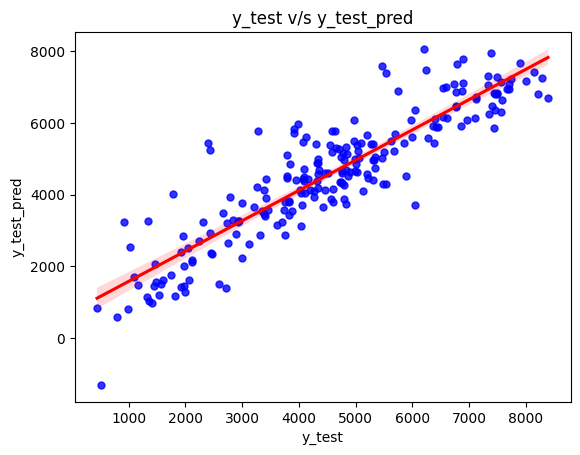

In [2443]:
# Visualize the predicted model using a scatter plot with a linear regression fit line
sns.regplot(x = y_test, y = y_test_pred, line_kws = { 'color': 'red' }, scatter_kws = { 's' : 25, 'color': 'blue' })

# Show the plot
plt.title('y_test v/s y_test_pred')
plt.xlabel('y_test')
plt.ylabel('y_test_pred') 
plt.show()

### Equation of the best fit line

In a multivariate linear regression model, the equation of the best-fit line is given by:

$Y = $$\beta_0$$ + $$\beta_1X_1$$ + $$\beta_2X_2$$ + $$\ldots$$ + $$\beta_nX_n$

- \( Y \): Dependent variable (the variable being predicted), `cnt` in this case.
- \( $\beta_0$ ): Y-intercept

- ( $\beta_1$, $\beta_2$, $\ldots$, $\beta_n$ ): Coefficients for the independent variables ( $X_1$, $X_2$, $\ldots$, $X_n$ \) respectively.

The coefficients are determined through a process that minimizes the sum of squared differences between predicted and actual values. The resulting line provides the best linear fit to the multivariate data.

For our model, the best fit line is determined by the following equation:

***cnt*** = 4491.30 + 995.75 x ***yr*** + -133.20 x ***holiday*** + 1120.81 x ***temp*** -226.30 x ***hum*** -272.75 x ***windspeed*** + 341.16 x ***Summer*** + 527.80 x ***Winter*** + 252.23 x ***September*** -204.50 x ***Cloudy***  -339.317 x ***Snow***

## Conclusion

- The equation of the best fit line is given by:
    - ***cnt*** = 4491.30 + 995.75 x ***yr*** + -133.20 x ***holiday*** + 1120.81 x ***temp*** -226.30 x ***hum*** -272.75 x ***windspeed*** + 341.16 x ***Summer*** + 527.80 x ***Winter*** + 252.23 x ***September*** -204.50 x ***Cloudy***  -339.317 x ***Snow***
- The close alignment of R2 between the training and test sets  (0.84 vs. 0.80) in a linear regression model indicates effective generalization. This  suggests the model avoids overfitting to the training data and is likely to perform consistently on new, unseen data.
- Bike demand is influenced by features such as **yr**, **holiday**, **temp**, **hum**, **windspeed**, **Summer**, **Winter**, **September**, **cloudy** and **snow**.
- Three key feature variables, **temp**, **yr**, and **Winter**, exhibit the highest coefficient values, indicating their significant impact.

# Recommendations

***Leverage High-Impact Features:*** Focus on features such as temp, yr, and Winter as they exhibit the highest coefficient values, indicating significant impact on bike demand.

***Seasonal Strategies:*** Develop targeted marketing and pricing strategies for different seasons, particularly emphasizing promotions during Summer and Winter.

***Optimize Operational Planning:*** Adjust bike availability and distribution based on the significant features identified, optimizing resources for peak demand periods.


***Weather-Sensitive Promotions:*** Implement weather-specific promotions or incentives to encourage bike usage during favorable weather conditions, addressing the impact of temp, hum, and windspeed.

***New Market Insights:*** Use the developed model to gain insights into demand dynamics in the American market, informing business strategies and positioning BoomBikes competitively.

***Continuous Monitoring and Adaptation:*** Regularly update the model with new data and adapt strategies based on evolving market conditions to ensure sustained revenue growth.